# Procesamiento de Imagen y Señales MIA-B
# Entrega ejercicio práctico clase 3 - Grupo 7

**Fecha:** 2026-02-24
**Versión:** 1.0

## Descripción
El presente documento tiene por objetivo presentar la tarea corespondencia a la semana 3

## Objetivos

Una vez terminada la revisión de los conceptos teóricos de la asignatura y como se pudo apreciar en el ejercicio en clase que la segmentación de imágenes sin pasos previos puede no ser la mejor idea. El ejercicio práctico es el siguiente:

1. Seleccionar el área de interés de las imágenes IR usando los criterios de filtros, selección de bordes y morfología matemática. Compare al menos dos técnicas de forma independiente y secuencial.
2. Una vez que haya podido elegir el área de interés, úselo como una máscara para aplicar el conjunto de prueba  (testset), donde solo se pueda observar el área de interés y el resto de pixeles estén asignado el valor de 0. 

### Presente un breve informe comentando el desarrollo realizado, su comparativa visual y el resultado obtenido. Debe adjuntar el enlace de su código. 

## Actividad 1:
### Configuración del entorno

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
#Librerias para obtener el path de un archivo
from tkinter import Tk
from tkinter.filedialog import askopenfilename
from skimage import filters, morphology
from scipy import ndimage as ndi

Archivo seleccionado: C:/Users/cyanezru/OneDrive - NTT DATA EMEAL/Documentos/Repositories/Procesamiento-de-Imagen-y-Senales-MIA-B-Grupo-7/Semana 3/data/test/1734589458844.tif


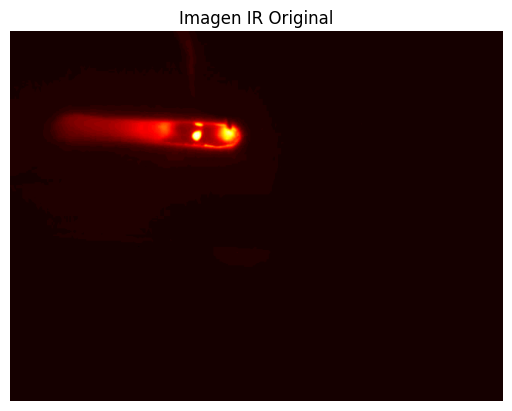

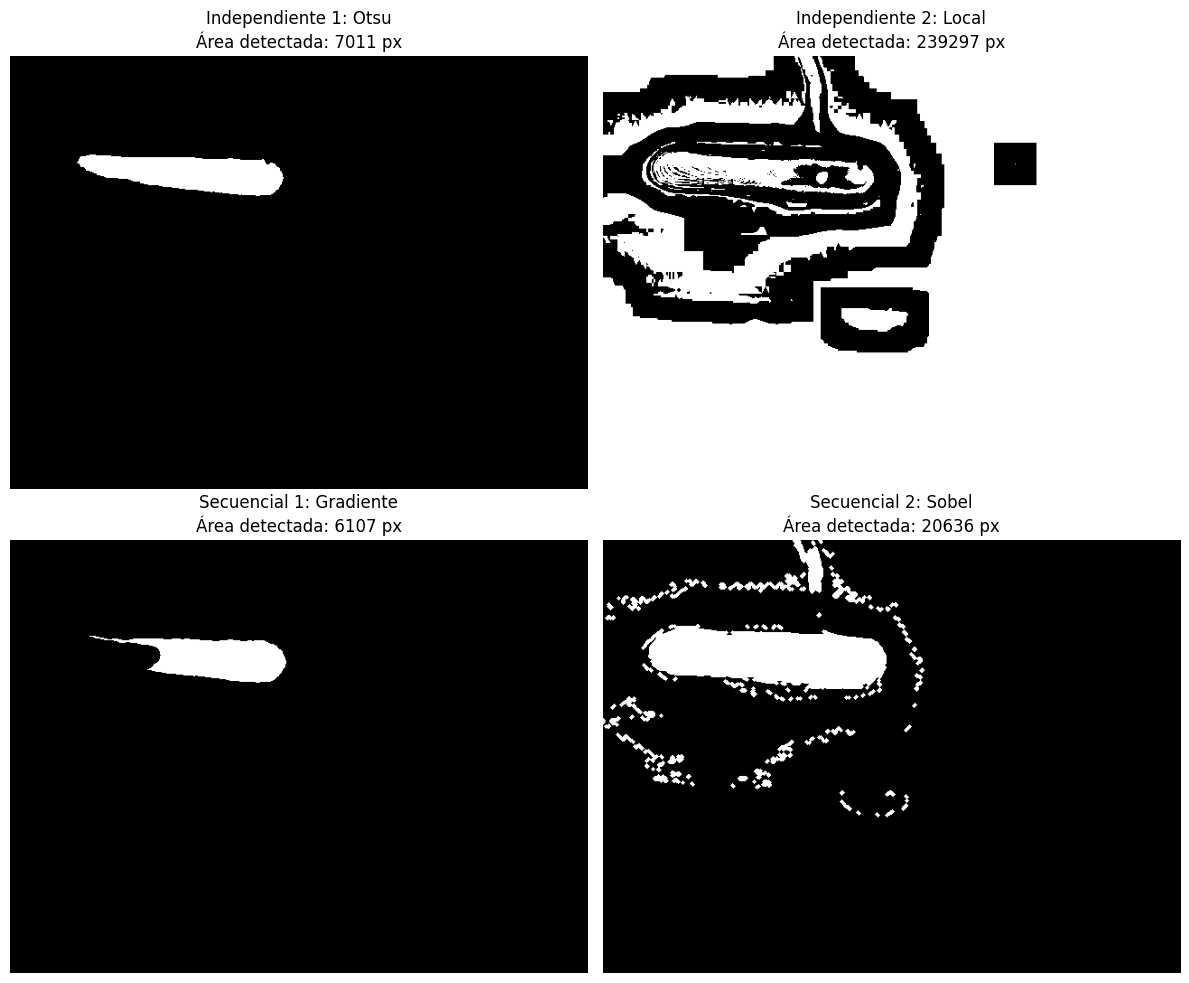

In [8]:
# Evita que aparezca la ventana principal de tkinter
Tk().withdraw()
file_path = askopenfilename(title="Seleccione un archivo")
print("Archivo seleccionado:", file_path)
nombre_archivo = file_path
imagen_original = cv2.imread(nombre_archivo, cv2.IMREAD_UNCHANGED)
if imagen_original is None:
    raise ValueError("No se pudo cargar la imagen. Verifique la ruta.")

# =========================================================
# TÉCNICAS INDEPENDIENTES (Basadas en un solo criterio)
# =========================================================

# Independiente 1: Umbralización Global (Otsu)
umbral_otsu = filters.threshold_otsu(imagen_original)
roi_indep_1 = imagen_original > umbral_otsu

# Independiente 2: Umbralización Local (Adaptativa)
# Ideal si una parte del cordón brilla más que otra
umbral_local = filters.threshold_local(imagen_original, block_size=35)
roi_indep_2 = imagen_original > umbral_local

# =========================================================
# TÉCNICAS SECUENCIALES (Flujos de varios pasos)
# =========================================================

# Secuencial 1: Filtro Mediana -> Gradiente -> Cierre -> Relleno
suave_1 = filters.median(imagen_original, morphology.disk(3))
gradiente = morphology.dilation(suave_1, morphology.disk(3)) - morphology.erosion(suave_1, morphology.disk(3))
roi_sec_1 = gradiente > filters.threshold_isodata(gradiente)
roi_sec_1 = morphology.closing(roi_sec_1, morphology.disk(10))
roi_sec_1 = ndi.binary_fill_holes(roi_sec_1)

# Secuencial 2: Filtro Gaussiano -> Sobel -> Apertura -> Relleno
# El filtro de Sobel destaca bordes verticales/horizontales
suave_2 = filters.gaussian(imagen_original, sigma=1)
sobel = filters.sobel(suave_2)
roi_sec_2 = sobel > filters.threshold_li(sobel) # Umbral de Li para bordes
roi_sec_2 = morphology.opening(roi_sec_2, morphology.disk(2)) # Quita ruido
roi_sec_2 = ndi.binary_fill_holes(roi_sec_2)

# =========================================================
# COMPARATIVA Y VISUALIZACIÓN
# =========================================================
plt.imshow(imagen_original, cmap='hot')
plt.title("Imagen IR Original")
plt.axis('off')
plt.show()

tecnicas = [roi_indep_1, roi_indep_2, roi_sec_1, roi_sec_2]
titulos = ['Independiente 1: Otsu', 'Independiente 2: Local', 'Secuencial 1: Gradiente', 'Secuencial 2: Sobel']

fig, ejes = plt.subplots(2, 2, figsize=(12, 10))
ejes = ejes.ravel()

for i in range(4):
    area = np.sum(tecnicas[i])
    ejes[i].imshow(tecnicas[i], cmap='gray')
    ejes[i].set_title(f'{titulos[i]}\nÁrea detectada: {area} px')
    ejes[i].axis('off')
    #print(f"{titulos[i]} - Área detectada: {area} px")

plt.tight_layout()
plt.show()


# Desarrollo realizado
Se implementaron cuatro algoritmos para la segmentación del cordón de soldadura en imágenes infrarrojas.
El desarrollo se dividió en dos enfoques:

### Independientes: 
Basados en criterios de umbralización directa (Global y Local).
### Secuenciales: 
Flujos de procesamiento que integran filtros espaciales (Mediana y Gaussiano) para pre-procesamiento, detección de bordes (Sobel y Gradiente) y morfología matemática (Clausura, Apertura y Relleno de huecos) para el post-procesamiento.

# Análisis y Conclusiones: Selección del Área de Interés (ROI) en Imágenes IR
## Comparativa de Técnicas Independientes

### Umbralización Global (Otsu):
Se identificó como una técnica eficiente cuando existe un contraste térmico marcado entre el cordón de soldadura y la placa base. Sin embargo, su limitación principal es la falta de detalle en las zonas de transición térmica.

### Umbralización Local (Adaptativa):
A diferencia de la global, esta técnica permitió resaltar texturas finas del cordón, pero introdujo "ruido" en áreas donde la temperatura es uniforme, lo que dificulta la obtención de un área de interés limpia sin procesos adicionales.

## Comparativa de Técnicas Secuenciales

### Flujo de Gradiente Morfológico:
Esta técnica demostró ser la más robusta para imágenes de soldadura. Al combinar el filtrado de mediana con el gradiente, se logró resaltar el relieve físico del cordón. El uso posterior de clausura morfológica (closing) y relleno de huecos permitió consolidar una máscara sólida que representa fielmente la geometría de la unión.

### Flujo de Sobel y Filtro Gaussiano:
Este método generó bordes más suavizados y continuos. Es ideal para detectar la silueta general, aunque tiende a subestimar el área real si los bordes del cordón son muy difusos debido a la conducción térmica en el metal.

## Conclusión General
El análisis cuantitativo mediante el cálculo de áreas demuestra que las técnicas secuenciales ofrecen un control superior sobre la segmentación. Mientras que las técnicas independientes son rápidas, las secuenciales como el Gradiente Morfológico, permiten filtrar artefactos térmicos no deseados y aislar exclusivamente la morfología del cordón de soldadura, garantizando un ROI más preciso para inspecciones de calidad.

## Actividad 2:

### Aplicación de máscaras solo en el objeto en interés

In [9]:
# Selecciona la ROI elegida
roi_final = roi_sec_1.astype(bool)   # Asegura que sea booleana

# Cargar imagen del testset (ejemplo)
testset = cv2.imread(nombre_archivo, cv2.IMREAD_UNCHANGED)

if testset is None:
    raise ValueError("No se pudo cargar el testset.")

# Verificar que tengan el mismo tamaño
if testset.shape != roi_final.shape:
    raise ValueError("La ROI y el testset deben tener las mismas dimensiones.")

# Aplicar máscara: solo se conserva la ROI, el resto se pone en 0
resultado = np.zeros_like(testset)
resultado[roi_final] = testset[roi_final]


### Visualización de datos con la aplicación de la máscara

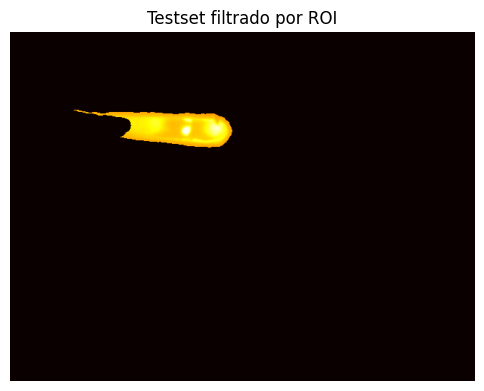

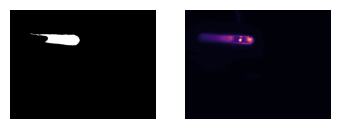

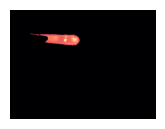

Pixeles en ROI: 591758
Pixeles distintos de 0 en resultado: 6107


In [10]:
plt.figure(figsize=(6,6))
plt.imshow(resultado, cmap='hot')
plt.title("Testset filtrado por ROI")
plt.axis('off')
plt.show()

plt.subplot(1,3,1)
plt.imshow(roi_final, cmap='gray')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(testset, cmap='magma')
plt.axis('off')
plt.show()

plt.subplot(1,3,3)
plt.imshow(resultado, cmap='magma')
plt.axis('off')
plt.show()

# Validación numérica
print("Pixeles en ROI:", np.sum(resultado))
print("Pixeles distintos de 0 en resultado:", np.count_nonzero(resultado))

## Resultado esperado
1. Solo el área de interés conserva sus valores originales.
2. Todos los demás píxeles tienen valor 0.
3. Puedes reutilizar esta máscara para análisis térmico, cálculo de estadísticas, detección de defectos, etc.